In [1]:

!pip -q install kagglehub

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


In [2]:

def read_csv_safe(file_path):
    encodings = ['utf-8', 'utf-8-sig', 'latin1', 'cp1252', 'ISO-8859-1']
    last_error = None
    for enc in encodings:
        try:
            df = pd.read_csv(file_path, encoding=enc)
            print(f"Файл успішно прочитано з кодуванням: {enc}")
            return df
        except Exception as e:
            last_error = e
    raise last_error

def find_csv_file(path):
    csv_files = [f for f in os.listdir(path) if f.lower().endswith('.csv')]
    if not csv_files:
        raise FileNotFoundError("CSV-файл не знайдено.")
    print("CSV files:", csv_files)
    return os.path.join(path, csv_files[0])


## Завдання 1. Global YouTube Statistics 2023

In [3]:

path1 = kagglehub.dataset_download("nelgiriyewithana/global-youtube-statistics-2023")
print("Path to dataset files:", path1)
print("Files in dataset folder:", os.listdir(path1))

csv_file1 = find_csv_file(path1)

youtube_df = read_csv_safe(csv_file1)

print("Перші 5 рядків датасету:")
display(youtube_df.head())

print("Розміри датасету:", youtube_df.shape)
print("Назви стовпців:")
print(list(youtube_df.columns))


100%|██████████| 60.1k/60.1k [00:00<00:00, 19.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nelgiriyewithana/global-youtube-statistics-2023/versions/1
Files in dataset folder: ['Global YouTube Statistics.csv']
CSV files: ['Global YouTube Statistics.csv']
Файл успішно прочитано з кодуванням: latin1
Перші 5 рядків датасету:


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,lowest_yearly_earnings,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,1.0,1.0,1.0,2.258000e+09,564600.0,9000000.00,6800000.00,1.084000e+08,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,4055159.0,7670.0,7423.0,1.200000e+01,0.0,0.05,0.04,5.800000e-01,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,48.0,1.0,1.0,1.348000e+09,337000.0,5400000.00,4000000.00,6.470000e+07,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,2.0,2.0,1.0,1.975000e+09,493800.0,7900000.00,5900000.00,9.480000e+07,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,3.0,2.0,2.0,1.824000e+09,455900.0,7300000.00,5500000.00,8.750000e+07,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


Розміри датасету: (995, 28)
Назви стовпців:
['rank', 'Youtuber', 'subscribers', 'video views', 'category', 'Title', 'uploads', 'Country', 'Abbreviation', 'channel_type', 'video_views_rank', 'country_rank', 'channel_type_rank', 'video_views_for_the_last_30_days', 'lowest_monthly_earnings', 'highest_monthly_earnings', 'lowest_yearly_earnings', 'highest_yearly_earnings', 'subscribers_for_last_30_days', 'created_year', 'created_month', 'created_date', 'Gross tertiary education enrollment (%)', 'Population', 'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude']


In [4]:

print("Кількість пропусків до обробки:")
print(youtube_df.isna().sum())


Кількість пропусків до обробки:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_month               

In [5]:

youtube_clean = youtube_df.copy()

for col in youtube_clean.columns:
    youtube_clean[col] = youtube_clean[col].replace(['nan', 'None', '', ' '], np.nan)

for col in youtube_clean.columns:
    if youtube_clean[col].dtype == 'object':
        youtube_clean[col] = youtube_clean[col].astype(str).str.replace(',', '', regex=False)
        youtube_clean[col] = youtube_clean[col].replace(['nan', 'None', '', ' '], np.nan)

for col in youtube_clean.columns:
    if youtube_clean[col].dtype == 'object':
        converted = pd.to_numeric(youtube_clean[col], errors='coerce')
        if converted.notna().sum() >= len(youtube_clean[col]) * 0.5:
            youtube_clean[col] = converted

print("Кількість пропусків після заміни на NaN та приведення типів:")
print(youtube_clean.isna().sum())


Кількість пропусків після заміни на NaN та приведення типів:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5

In [6]:

numeric_cols = youtube_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    youtube_clean[col] = youtube_clean[col].fillna(youtube_clean[col].mean()).astype(float)

print("Числові стовпці:")
print(list(numeric_cols))


Числові стовпці:
['rank', 'subscribers', 'video views', 'uploads', 'video_views_rank', 'country_rank', 'channel_type_rank', 'video_views_for_the_last_30_days', 'lowest_monthly_earnings', 'highest_monthly_earnings', 'lowest_yearly_earnings', 'highest_yearly_earnings', 'subscribers_for_last_30_days', 'created_year', 'created_date', 'Gross tertiary education enrollment (%)', 'Population', 'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude']


In [7]:

print("Кількість пропусків після заповнення:")
print(youtube_clean.isna().sum())


Кількість пропусків після заповнення:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             0
country_rank                                 0
channel_type_rank                            0
video_views_for_the_last_30_days             0
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days                 0
created_year                                 0
created_month         

In [8]:

country_col = None
for c in youtube_clean.columns:
    if str(c).strip().lower() == 'country':
        country_col = c
        break

if country_col:
    print("Кількість унікальних країн:", youtube_clean[country_col].nunique(dropna=True))
else:
    print("Стовпець Country не знайдено.")


Кількість унікальних країн: 49


In [9]:

views_col = None
for c in youtube_clean.columns:
    if str(c).strip().lower() in ['video views', 'video_views', 'videoviews', 'views']:
        views_col = c
        break

print("Стовпець із переглядами:", views_col)


Стовпець із переглядами: video views


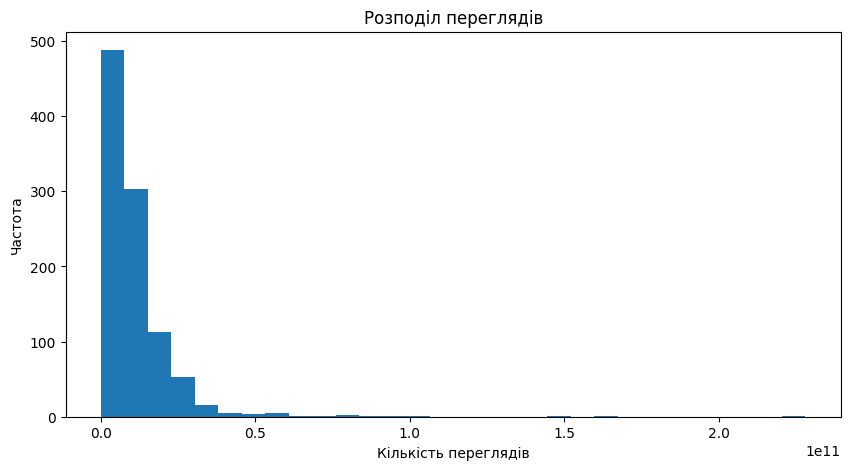

In [10]:

if views_col:
    youtube_clean[views_col].plot(kind='hist', bins=30, figsize=(10, 5))
    plt.title('Розподіл переглядів')
    plt.xlabel('Кількість переглядів')
    plt.ylabel('Частота')
    plt.show()
else:
    print("Стовпець із переглядами не знайдено.")


In [11]:

if views_col:
    print("Максимальна кількість переглядів:", youtube_clean[views_col].max())
    print("Мінімальна кількість переглядів:", youtube_clean[views_col].min())
    print("Середня кількість переглядів:", youtube_clean[views_col].mean())
else:
    print("Стовпець із переглядами не знайдено.")


Максимальна кількість переглядів: 228000000000.0
Мінімальна кількість переглядів: 0.0
Середня кількість переглядів: 11039537052.03819


In [12]:

uploads_col = None
for c in youtube_clean.columns:
    if str(c).strip().lower() == 'uploads':
        uploads_col = c
        break

if country_col and uploads_col:
    country_uploads = youtube_clean.groupby(country_col)[uploads_col].sum().sort_values(ascending=False)
    print("Країна, де найбільше відео було завантажено на YouTube:")
    print(country_uploads.idxmax(), '-', country_uploads.max())
else:
    print("Не знайдено потрібні стовпці Country та/або uploads.")


Країна, де найбільше відео було завантажено на YouTube:
India - 3728212.0


In [13]:

name_col = None
for c in youtube_clean.columns:
    if str(c).strip().lower() in ['youtuber', 'channel name', 'channel_name']:
        name_col = c
        break

if uploads_col and name_col:
    max_row = youtube_clean.loc[youtube_clean[uploads_col].idxmax()]
    min_row = youtube_clean.loc[youtube_clean[uploads_col].idxmin()]

    print("Канал з найбільшою кількістю uploads:")
    print(max_row[name_col], '-', max_row[uploads_col])

    print("\nКанал з найменшою кількістю uploads:")
    print(min_row[name_col], '-', min_row[uploads_col])
else:
    print("Не знайдено потрібні стовпці для назви каналу або uploads.")


Канал з найбільшою кількістю uploads:
ABP NEWS - 301308.0

Канал з найменшою кількістю uploads:
Music - 0.0


## Завдання 2. Amazon Top 50 Bestselling Books 2009–2019

In [14]:

path2 = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")
print("Path to dataset files:", path2)
print("Files in dataset folder:", os.listdir(path2))

csv_file2 = find_csv_file(path2)

books_df = read_csv_safe(csv_file2)

print("Перші 10 рядків:")
display(books_df.head(10))

print("Розміри датасету:", books_df.shape)
print("Датасет містить дані про таку кількість книг:", books_df.shape[0])


100%|██████████| 14.5k/14.5k [00:00<00:00, 9.64MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sootersaalu/amazon-top-50-bestselling-books-2009-2019/versions/1
Files in dataset folder: ['bestsellers with categories.csv']
CSV files: ['bestsellers with categories.csv']
Файл успішно прочитано з кодуванням: utf-8
Перші 10 рядків:


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
5,A Dance with Dragons (A Song of Ice and Fire),George R. R. Martin,4.4,12643,11,2011,Fiction
6,A Game of Thrones / A Clash of Kings / A Storm...,George R. R. Martin,4.7,19735,30,2014,Fiction
7,A Gentleman in Moscow: A Novel,Amor Towles,4.7,19699,15,2017,Fiction
8,"A Higher Loyalty: Truth, Lies, and Leadership",James Comey,4.7,5983,3,2018,Non Fiction
9,A Man Called Ove: A Novel,Fredrik Backman,4.6,23848,8,2016,Fiction


Розміри датасету: (550, 7)
Датасет містить дані про таку кількість книг: 550


In [15]:

books_df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
print("Нові назви стовпців:")
print(books_df.columns.tolist())


Нові назви стовпців:
['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']


In [16]:

missing_books = books_df.isna().sum()
print("Кількість пропусків:")
print(missing_books)

if missing_books.sum() == 0:
    print("Чи є в якихось змінних пропуски? Ні")
else:
    print("Чи є в якихось змінних пропуски? Так")


Кількість пропусків:
name           0
author         0
user_rating    0
reviews        0
price          0
year           0
genre          0
dtype: int64
Чи є в якихось змінних пропуски? Ні


In [17]:

print("Унікальні жанри:")
print(books_df['genre'].unique())


Унікальні жанри:
['Non Fiction' 'Fiction']


In [18]:

print("Максимальна ціна:", books_df['price'].max())
print("Мінімальна ціна:", books_df['price'].min())
print("Середня ціна:", books_df['price'].mean())
print("Медіанна ціна:", books_df['price'].median())


Максимальна ціна: 105
Мінімальна ціна: 0
Середня ціна: 13.1
Медіанна ціна: 11.0


In [19]:

max_rating = books_df['user_rating'].max()
print("Найвищий рейтинг у датасеті:", max_rating)

count_max_rating = books_df[books_df['user_rating'] == max_rating].shape[0]
print("Скільки книг мають такий рейтинг:", count_max_rating)

book_max_reviews = books_df.loc[books_df['reviews'].idxmax(), 'name']
print("Яка книга має найбільше відгуків:", book_max_reviews)

most_expensive_2010 = books_df[books_df['year'] == 2010].sort_values(by='price', ascending=False).head(1)
print("Найдорожча книга серед Топ-50 у 2010 році:")
display(most_expensive_2010[['name', 'price']])

fiction_2012_count = books_df[(books_df['genre'] == 'Fiction') & (books_df['year'] == 2012)].shape[0]
print("Скільки книг жанру Fiction потрапили до Топ-50 у 2012 році:", fiction_2012_count)

rating_49_count = books_df[(books_df['user_rating'] == 4.9) & (books_df['year'].isin([2010, 2011]))].shape[0]
print("Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках:", rating_49_count)


Найвищий рейтинг у датасеті: 4.9
Скільки книг мають такий рейтинг: 52
Яка книга має найбільше відгуків: Where the Crawdads Sing
Найдорожча книга серед Топ-50 у 2010 році:


,name,price
272,Publication Manual of the American Psychologic...,46


Скільки книг жанру Fiction потрапили до Топ-50 у 2012 році: 21
Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках: 1


In [20]:

genre_price = books_df.groupby('genre')[['price']].agg(['min', 'max'])
print("Мінімальна і максимальна ціна для кожного жанру:")
display(genre_price)


Мінімальна і максимальна ціна для кожного жанру:


price     
              min  max
genre                 
Fiction         0   82
Non Fiction     0  105

In [21]:

youtube_clean.to_csv('youtube_cleaned.csv', index=False)
books_df.to_csv('books_cleaned.csv', index=False)

print("Файли youtube_cleaned.csv та books_cleaned.csv збережено.")


Файли youtube_cleaned.csv та books_cleaned.csv збережено.



## Висновок

У ході лабораторної роботи було виконано аналіз двох датасетів у форматі CSV.  
Для першого набору даних було проведено зчитування, перевірку структури, пошук пропусків, перетворення числових значень, заповнення пропущених даних середніми значеннями, побудову гістограми та обчислення основних статистичних показників.

